In [ ]:
pip install pandas sqlalchemy pyodbc scikit-learn matplotlib seaborn joblib

In [4]:
import pyodbc
import pandas as pd

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-F4E70B6\\SQLEXPRESS01;"
    "DATABASE=Marketing_ETL_AI;"
    "Trusted_Connection=yes;"
)

query = "SELECT  * FROM dbo.vw_customer_clustering"

df = pd.read_sql(query, conn)

df.head()

C:\Users\Sai\AppData\Local\Temp\ipykernel_16748\291837338.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,ID,Age,Income,Total_Children,Recency,Customer_Tenure_Days,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Total_Campaigns_Accepted,Complain,Response,Education,Marital_Status
0,5524,69,58138.0,0,58,NaN,1617,25,3,8,10,4,7,0,0,1,Graduation,Single
1,2174,72,46344.0,2,38,NaN,27,6,2,1,1,2,5,0,0,0,Graduation,Single
2,4141,61,71613.0,0,26,4649.0,776,21,1,8,2,10,4,0,0,0,Graduation,Together
3,6182,42,26646.0,1,26,NaN,53,8,2,2,0,4,6,0,0,0,Graduation,Together
4,5324,45,58293.0,1,94,4498.0,422,19,5,5,3,6,5,0,0,0,PhD,Married


In [17]:
df.shape

(2237, 18)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2237 entries, 0 to 2236
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        2237 non-null   int64  
 1   Age                       2237 non-null   int64  
 2   Income                    2237 non-null   float64
 3   Total_Children            2237 non-null   int64  
 4   Recency                   2237 non-null   int64  
 5   Customer_Tenure_Days      1321 non-null   float64
 6   Total_Spending            2237 non-null   int64  
 7   Total_Purchases           2237 non-null   int64  
 8   NumDealsPurchases         2237 non-null   int64  
 9   NumWebPurchases           2237 non-null   int64  
 10  NumCatalogPurchases       2237 non-null   int64  
 11  NumStorePurchases         2237 non-null   int64  
 12  NumWebVisitsMonth         2237 non-null   int64  
 13  Total_Campaigns_Accepted  2237 non-null   int64  
 14  Complain

In [21]:
df.isnull()

,ID,Age,Income,Total_Children,Recency,Customer_Tenure_Days,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Total_Campaigns_Accepted,Complain,Response,Education,Marital_Status
0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2232,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2233,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2234,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2235,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [23]:
df.isnull().sum()

ID                            0
Age                           0
Income                        0
Total_Children                0
Recency                       0
Customer_Tenure_Days        916
Total_Spending                0
Total_Purchases               0
NumDealsPurchases             0
NumWebPurchases               0
NumCatalogPurchases           0
NumStorePurchases             0
NumWebVisitsMonth             0
Total_Campaigns_Accepted      0
Complain                      0
Response                      0
Education                     0
Marital_Status                0
dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2237 entries, 0 to 2236
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        2237 non-null   int64  
 1   Age                       2237 non-null   int64  
 2   Income                    2237 non-null   float64
 3   Total_Children            2237 non-null   int64  
 4   Recency                   2237 non-null   int64  
 5   Customer_Tenure_Days      1321 non-null   float64
 6   Total_Spending            2237 non-null   int64  
 7   Total_Purchases           2237 non-null   int64  
 8   NumDealsPurchases         2237 non-null   int64  
 9   NumWebPurchases           2237 non-null   int64  
 10  NumCatalogPurchases       2237 non-null   int64  
 11  NumStorePurchases         2237 non-null   int64  
 12  NumWebVisitsMonth         2237 non-null   int64  
 13  Total_Campaigns_Accepted  2237 non-null   int64  
 14  Complain

In [27]:
df["Customer_Tenure_Days"].median()

4680.0

In [29]:
df["Customer_Tenure_Days"] = df["Customer_Tenure_Days"].fillna(
    df["Customer_Tenure_Days"].median()
)

In [31]:
df.isnull().sum()

ID                          0
Age                         0
Income                      0
Total_Children              0
Recency                     0
Customer_Tenure_Days        0
Total_Spending              0
Total_Purchases             0
NumDealsPurchases           0
NumWebPurchases             0
NumCatalogPurchases         0
NumStorePurchases           0
NumWebVisitsMonth           0
Total_Campaigns_Accepted    0
Complain                    0
Response                    0
Education                   0
Marital_Status              0
dtype: int64

In [33]:
df.describe()

,ID,Age,Income,Total_Children,Recency,Customer_Tenure_Days,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Total_Campaigns_Accepted,Complain,Response
count,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000
mean,5590.726419,57.098346,52236.581563,0.950827,49.104604,4681.155565,605.743406,14.870809,2.326777,4.087170,2.662494,5.794367,5.319177,0.297720,0.008941,0.149307
std,3245.118591,11.701917,25043.111823,0.752037,28.956073,155.411319,601.840466,7.676593,1.932923,2.779461,2.923456,3.250940,2.426386,0.678615,0.094152,0.356471
min,0.000000,30.000000,1730.000000,0.000000,0.000000,4337.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2829.000000,49.000000,35523.000000,0.000000,24.000000,4624.000000,69.000000,8.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000
50%,5455.000000,56.000000,51717.000000,1.000000,49.000000,4680.000000,396.000000,15.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000
75%,8427.000000,67.000000,68281.000000,1.000000,74.000000,4738.000000,1045.000000,21.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000
max,11191.000000,86.000000,666666.000000,3.000000,99.000000,5036.000000,2525.000000,44.000000,15.000000,27.000000,28.000000,13.000000,20.000000,4.000000,1.000000,1.000000


In [6]:
cluster_df = df[
    [
        "Age",
        "Income",
        "Total_Children",
        "Recency",
        "Customer_Tenure_Days",
        "Total_Spending",
        "Total_Purchases",
        "NumDealsPurchases",
        "NumWebPurchases",
        "NumCatalogPurchases",
        "NumStorePurchases",
        "NumWebVisitsMonth",
        "Total_Campaigns_Accepted",
        "Education",
        "Marital_Status"
    ]
]

In [8]:
cluster_df.head()

,Age,Income,Total_Children,Recency,Customer_Tenure_Days,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Total_Campaigns_Accepted,Education,Marital_Status
0,69,58138.0,0,58,NaN,1617,25,3,8,10,4,7,0,Graduation,Single
1,72,46344.0,2,38,NaN,27,6,2,1,1,2,5,0,Graduation,Single
2,61,71613.0,0,26,4649.0,776,21,1,8,2,10,4,0,Graduation,Together
3,42,26646.0,1,26,NaN,53,8,2,2,0,4,6,0,Graduation,Together
4,45,58293.0,1,94,4498.0,422,19,5,5,3,6,5,0,PhD,Married


In [10]:
cluster_df = pd.get_dummies(
    cluster_df,
    columns=["Education", "Marital_Status"],
    drop_first=True
)

In [16]:
cluster_df.head()

,Age,Income,Total_Children,Recency,Customer_Tenure_Days,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,69,58138.0,0,58,NaN,1617,25,3,8,10,...,True,False,False,False,False,False,True,False,False,False
1,72,46344.0,2,38,NaN,27,6,2,1,1,...,True,False,False,False,False,False,True,False,False,False
2,61,71613.0,0,26,4649.0,776,21,1,8,2,...,True,False,False,False,False,False,False,True,False,False
3,42,26646.0,1,26,NaN,53,8,2,2,0,...,True,False,False,False,False,False,False,True,False,False
4,45,58293.0,1,94,4498.0,422,19,5,5,3,...,False,False,True,False,False,True,False,False,False,False


In [18]:
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()


In [28]:
scaled_data = scaler.fit_transform(cluster_df)

In [34]:
scaled_data[:5]

array([[ 1.01729612,  0.23570305, -1.26461829,  0.30727179,         nan,
         1.6806492 ,  1.31978541,  0.34837058,  1.40808041,  2.51043517,
        -0.55207689,  0.69288179, -0.43881555, -0.15727874,  0.99242919,
        -0.44517288, -0.52614303, -0.03664536, -0.33934427, -0.79327105,
         1.91576255, -0.59094494, -0.18880717, -0.02991412],
       [ 1.27372169, -0.23535011,  1.39542037, -0.38358403,         nan,
        -0.96183763, -1.15582425, -0.16909621, -1.11095662, -0.56880154,
        -1.16742119, -0.13157383, -0.43881555, -0.15727874,  0.99242919,
        -0.44517288, -0.52614303, -0.03664536, -0.33934427, -0.79327105,
         1.91576255, -0.59094494, -0.18880717, -0.02991412],
       [ 0.33349461,  0.77389547, -1.26461829, -0.79809753, -0.16299974,
         0.28295648,  0.79860443, -0.686563  ,  1.40808041, -0.22666412,
         1.293956  , -0.54380164, -0.43881555, -0.15727874,  0.99242919,
        -0.44517288, -0.52614303, -0.03664536, -0.33934427, -0.79327105,
  

In [38]:
cluster_df["Customer_Tenure_Days"] = cluster_df["Customer_Tenure_Days"].fillna(
    cluster_df["Customer_Tenure_Days"].median()
)

In [40]:
cluster_df.isnull().sum()

Age                         0
Income                      0
Total_Children              0
Recency                     0
Customer_Tenure_Days        0
Total_Spending              0
Total_Purchases             0
NumDealsPurchases           0
NumWebPurchases             0
NumCatalogPurchases         0
NumStorePurchases           0
NumWebVisitsMonth           0
Total_Campaigns_Accepted    0
Education_Basic             0
Education_Graduation        0
Education_Master            0
Education_PhD               0
Marital_Status_Alone        0
Marital_Status_Divorced     0
Marital_Status_Married      0
Marital_Status_Single       0
Marital_Status_Together     0
Marital_Status_Widow        0
Marital_Status_YOLO         0
dtype: int64

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_df)

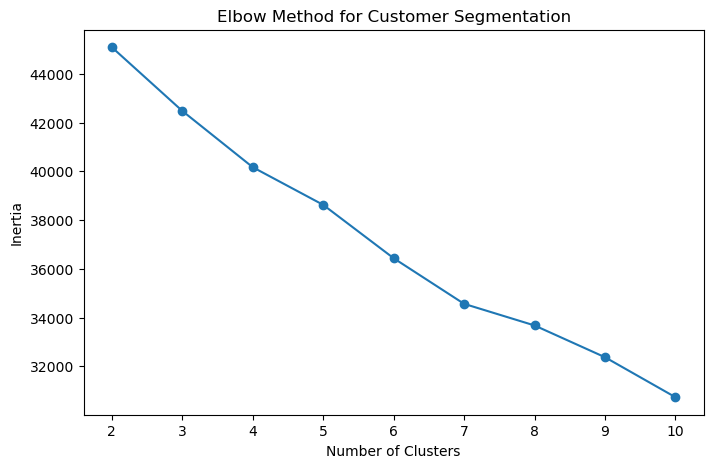

In [44]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Customer Segmentation")
plt.show()

In [46]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(scaled_data)

df.head()

,ID,Age,Income,Total_Children,Recency,Customer_Tenure_Days,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Total_Campaigns_Accepted,Complain,Response,Education,Marital_Status,Cluster
0,5524,69,58138.0,0,58,NaN,1617,25,3,8,10,4,7,0,0,1,Graduation,Single,2
1,2174,72,46344.0,2,38,NaN,27,6,2,1,1,2,5,0,0,0,Graduation,Single,1
2,4141,61,71613.0,0,26,4649.0,776,21,1,8,2,10,4,0,0,0,Graduation,Together,2
3,6182,42,26646.0,1,26,NaN,53,8,2,2,0,4,6,0,0,0,Graduation,Together,1
4,5324,45,58293.0,1,94,4498.0,422,19,5,5,3,6,5,0,0,0,PhD,Married,0


In [48]:
df["Cluster"].value_counts()

Cluster
1    975
0    610
2    598
3     54
Name: count, dtype: int64

In [50]:
cluster_summary = df.groupby("Cluster").agg({
    "Age": "mean",
    "Income": "mean",
    "Total_Children": "mean",
    "Recency": "mean",
    "Total_Spending": "mean",
    "Total_Purchases": "mean",
    "NumWebPurchases": "mean",
    "NumCatalogPurchases": "mean",
    "NumStorePurchases": "mean",
    "Total_Campaigns_Accepted": "mean",
    "Response": "mean"
}).round(2)

cluster_summary

,Age,Income,Total_Children,Recency,Total_Spending,Total_Purchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Total_Campaigns_Accepted,Response
Cluster,,,,,,,,,,,
0,60.66,56825.29,1.23,48.14,732.87,21.32,6.61,3.01,7.61,0.21,0.13
1,54.88,36062.88,1.24,49.35,98.72,7.78,2.07,0.55,3.23,0.09,0.09
2,57.85,76809.30,0.21,49.74,1350.04,20.56,5.00,5.95,8.39,0.75,0.28
3,48.54,20306.26,0.72,48.44,81.80,7.02,1.89,0.48,2.85,0.11,0.04


In [52]:
def assign_segment(cluster):
    if cluster == 0:
        return "Loyal Customers"
    elif cluster == 1:
        return "Budget Customers"
    elif cluster == 2:
        return "VIP Customers"
    else:
        return "Inactive Customers"

df["Segment_Name"] = df["Cluster"].apply(assign_segment)

df[["Cluster", "Segment_Name"]].head()

,Cluster,Segment_Name
0,2,VIP Customers
1,1,Budget Customers
2,2,VIP Customers
3,1,Budget Customers
4,0,Loyal Customers


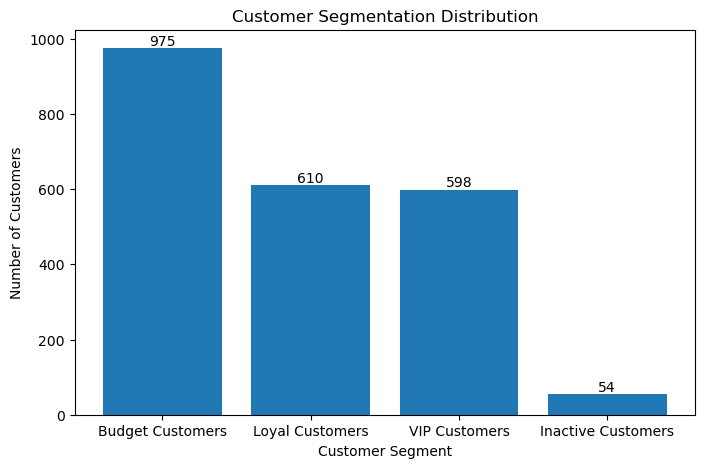

In [56]:
import matplotlib.pyplot as plt

cluster_counts = df["Segment_Name"].value_counts()

plt.figure(figsize=(8,5))

bars = plt.bar(
    cluster_counts.index,
    cluster_counts.values
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Segmentation Distribution")

# Add labels on top of bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

plt.show()

In [58]:
from sqlalchemy import create_engine
import urllib

params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-F4E70B6\\SQLEXPRESS01;"
    "DATABASE=Marketing_ETL_AI;"
    "Trusted_Connection=yes;"
)

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}"
)

df.to_sql(
    "customer_segments",
    con=engine,
    schema="dbo",
    if_exists="replace",
    index=False
)

53

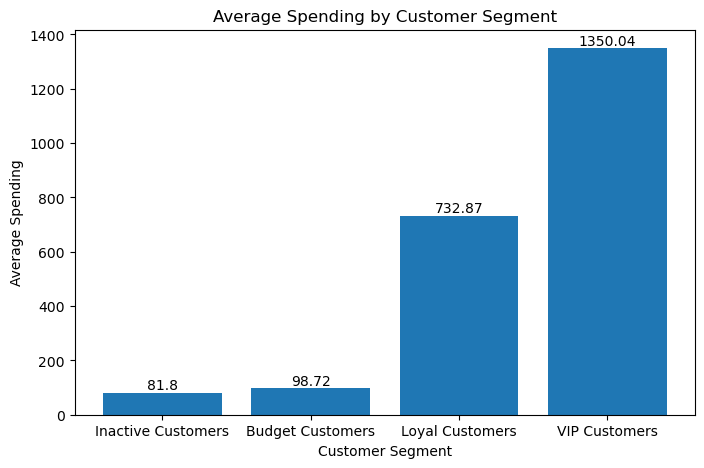

In [60]:
segment_spending = df.groupby("Segment_Name")["Total_Spending"].mean().sort_values()

plt.figure(figsize=(8,5))
bars = plt.bar(segment_spending.index, segment_spending.values)
plt.xlabel("Customer Segment")
plt.ylabel("Average Spending")
plt.title("Average Spending by Customer Segment")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, round(height, 2), ha="center", va="bottom")

plt.show()

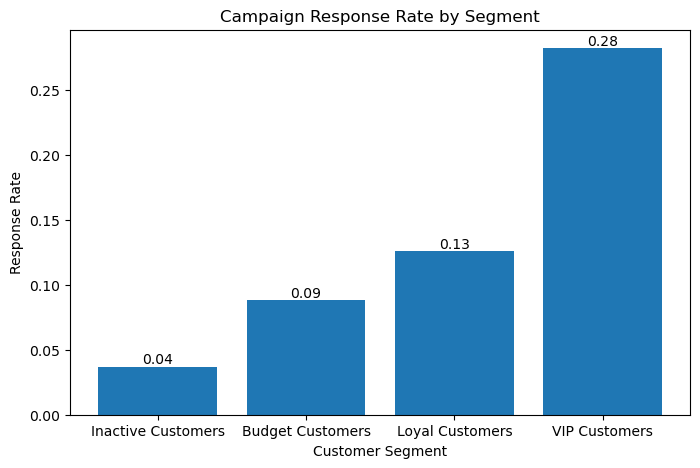

In [62]:
response_rate = df.groupby("Segment_Name")["Response"].mean().sort_values()

plt.figure(figsize=(8,5))
bars = plt.bar(response_rate.index, response_rate.values)
plt.xlabel("Customer Segment")
plt.ylabel("Response Rate")
plt.title("Campaign Response Rate by Segment")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, round(height, 2), ha="center", va="bottom")

plt.show()

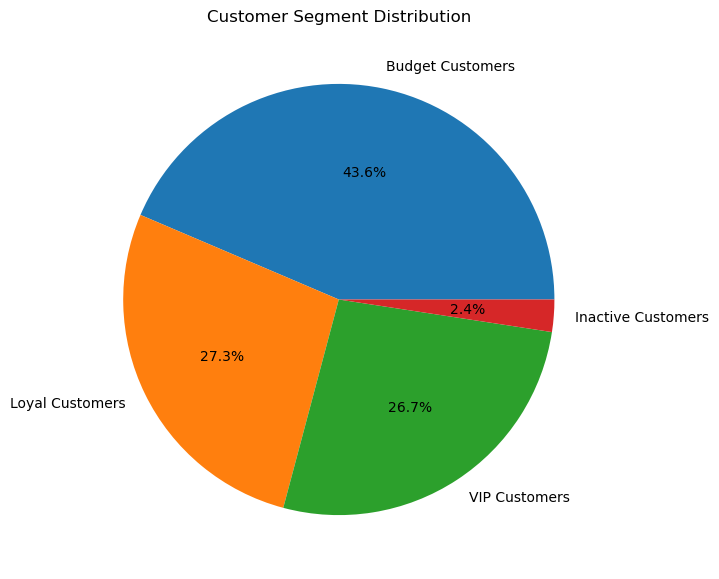

In [66]:
segment_counts = df["Segment_Name"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    segment_counts.values,
    labels=segment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Customer Segment Distribution")

plt.show()

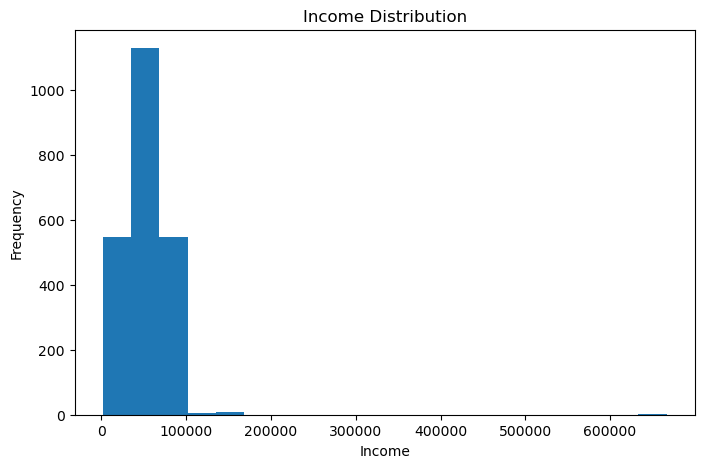

In [68]:
plt.figure(figsize=(8,5))

plt.hist(df["Income"], bins=20)

plt.xlabel("Income")
plt.ylabel("Frequency")
plt.title("Income Distribution")

plt.show()

In [70]:
import joblib

joblib.dump(kmeans, "customer_segmentation_model.pkl")

['customer_segmentation_model.pkl']

In [72]:
import os

os.getcwd()

'C:\\Users\\Sai'